# WP2/T2.5 DBRepo – load 
[Owner: C]

Verify whether the schema defined in T2.1 correctly models the data in 3NF. 

If so, prepare code to load
the input data into DBRepo using the REST API and verify that all views defined in T2.4 return correct
results.

*Author*: *Ambrogi Federico*

In [10]:
from dbrepo.RestClient import RestClient
from dbrepo.api.dto import (
    QueryDefinition,
    FilterDefinition,
    FilterType,
    OrderDefinition,
    OrderType,
)
import pandas as pd
import time
import os, sys

In [4]:
from dotenv import load_dotenv
load_dotenv("../.env")

ENDPOINT = "https://test.dbrepo.tuwien.ac.at"
USERNAME = os.getenv("DBREPO_USERNAME")
PASSWORD = os.getenv("DBREPO_PASSWORD")
DATABASE_ID = os.getenv("DBREPO_DATABASE_ID")


client = RestClient(
    endpoint=ENDPOINT,
    username=USERNAME,
    password=PASSWORD
)

print("Current user:", client.whoami())
print("Database ID:", DATABASE_ID)


federicoa88
Current user: federicoa88
Database ID: bfa4385b-54a9-4ae3-b4f4-cb503d7bb016


In [5]:
# VERIFY TABLES
tables = client.get_tables(DATABASE_ID)

for t in tables:
    print("Table: " , t.name)
    #print(t.description)
    print(t.id)

    print("-----")

stations
53688cc1-5205-4f25-af30-7feef2ea1b2b
-----
measurement_variables
7ed509f5-3356-4318-80b3-c6672b13c4b8
-----
precipitation_measurements
d11966e6-f0a6-460d-900b-b56e627fc752
-----


## Create a simple view

Using the preicpitations table



In [6]:
precipitations = 'd11966e6-f0a6-460d-900b-b56e627fc752'
stations = '53688cc1-5205-4f25-af30-7feef2ea1b2b'

TABLE_ID = precipitations

In [7]:
precipitations_data = client.get_table_data(database_id=DATABASE_ID,
                                        table_id=TABLE_ID)

precipitations_data.head(5)

,ca_flag,cd_flag,cl,cl_flag,k_flag,lf,lf_flag,measurement_id,mg_flag,na_flag,...,sample_date,so4,so4_flag,station_id,ca,k,mg,na,cd,pb
0,7.0,7.0,0.05,1.0,7.0,8.3,1.0,3849,7.0,7.0,...,2017-05-06,0.24,1.0,3,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,7.0,0.131,1.0,1.0,12.33,1.0,2666,1.0,1.0,...,2016-06-20,0.609,1.0,7,0.233,0.024,0.021,0.19,NaN,NaN
2,1.0,1.0,0.0317,1.0,1.0,6.34,1.0,5503,1.0,1.0,...,2018-05-22,0.4781,1.0,6,0.2503,0.0307,0.0199,0.034,0.0709421103048768,0.0004314250779881
3,1.0,7.0,0.313,1.0,1.0,7.42,1.0,119,1.0,1.0,...,2014-11-06,0.833,1.0,11,0.394,0.091,0.072,0.188,NaN,NaN
4,1.0,7.0,0.1276,1.0,1.0,14.27,1.0,5486,1.0,1.0,...,2018-05-17,1.291,1.0,7,0.7189,0.1297,0.0594,0.1011,NaN,NaN


In [8]:
TABLE_NAME = 'precipitation_measurements'

## View for station_id=2 to build a time series for Cd, Pb and pH
view_query = QueryDefinition(
    datasources=[TABLE_NAME],
    
    columns=[
        f"{TABLE_NAME}.station_id",
        f"{TABLE_NAME}.cd",
        f"{TABLE_NAME}.pb",
        f"{TABLE_NAME}.ph",
        f"{TABLE_NAME}.lf",
        f"{TABLE_NAME}.ns",
        f"{TABLE_NAME}.measurement_id",
    ],

    filters=[
        FilterDefinition(
            type=FilterType.WHERE,
            column=f"{TABLE_NAME}.station_id",
            operator="=",
            value="6",
        )
    ],
    orders=[
        OrderDefinition(
            column=f"{TABLE_NAME}.measurement_id",
            direction=OrderType.DESC,
        )
    ],
)


view = client.create_view(
    database_id=DATABASE_ID,
    name="station_6_data_pb_cd_ph",
    query=view_query,
    is_public=False,
    is_schema_public=False,
)

print("Created view id:", view.id)
print("Created view name:", view.name)

VIEW_ID = view.id

ForbiddenError: Failed to create view: not allowed

In [11]:
print("Waiting for asynchronous view creation to map...")
time.sleep(5)

for _ in range(10):
    try:
        df_view = client.get_view_data(
            database_id=DATABASE_ID,
            view_id=VIEW_ID,
            page=0,
            size=1000000,
        )
        print('df from VIEW created *** ')
        break
    except Exception as e:
        if '204' in str(e):
            print("Still waiting for view...")
            time.sleep(5)
        else:
            raise e


station_6_data_pb_cd_ph = df_view

Waiting for asynchronous view creation to map...


NameError: name 'VIEW_ID' is not defined

In [119]:
station_6_data_pb_cd_ph

,cd,lf,measurement_id,ns,pb,ph,station_id
0,0.052060101252439,2.44,3232,4.4,0.0003297943351134,5.53,6
1,0.027318738960215,3.47,6148,1.9,0.1531179260695796,5.96,6
2,0.0278451214505088,8.65,6045,6.0,0.0008781305596216,5.09,6
3,0.003647342585645,1.62,74,18.3,3.34484407933862e-05,5.73,6
4,0.09,4.53,1728,2.3,0.0065,6.14,6
...,...,...,...,...,...,...,...
975,0.0332911417559606,5.73,6114,9.0,0.1078371117434042,6.3,6
976,0.0005709878030909,2.55,478,8.0,7.689268533817829e-05,5.51,6
977,0.0125853316011083,2.22,6558,26.9,0.1418911185535384,5.61,6
978,NaN,NaN,3339,6.7,NaN,NaN,6


In [120]:
station_6_data_pb_cd_ph.head()

,cd,lf,measurement_id,ns,pb,ph,station_id
0,0.052060101252439,2.44,3232,4.4,0.0003297943351134,5.53,6
1,0.027318738960215,3.47,6148,1.9,0.1531179260695796,5.96,6
2,0.0278451214505088,8.65,6045,6.0,0.0008781305596216,5.09,6
3,0.003647342585645,1.62,74,18.3,3.34484407933862e-05,5.73,6
4,0.09,4.53,1728,2.3,0.0065,6.14,6


In [12]:
import matplotlib.pyplot as plt

station_6_data_pb_cd_ph['measurement_id'] = station_6_data_pb_cd_ph['measurement_id'].astype('int').values
station_6_data_pb_cd_ph['ph'] = station_6_data_pb_cd_ph['ph'].astype('float').values
station_6_data_pb_cd_ph['cd'] = station_6_data_pb_cd_ph['cd'].astype('float').values
station_6_data_pb_cd_ph['pb'] = station_6_data_pb_cd_ph['pb'].astype('float').values

station_6_data_pb_cd_ph = station_6_data_pb_cd_ph.sort_values(by=['measurement_id'])

plt.title('ph of station_id = 6 from Retrieved VIEW')
plt.plot( list(station_6_data_pb_cd_ph['measurement_id']), list(station_6_data_pb_cd_ph['ph']), label= 'ph', color = 'blue')
plt.ylabel('ph - values')
ax = plt.gca()
ax.set_ylim([3, 8])
plt.show()

NameError: name 'station_6_data_pb_cd_ph' is not defined

In [52]:
# Verify retrieved data from the VIEW

# Load original file data precipitations.csv

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *

csv_path = "../data/precipitationdata.csv"
print('Failed DBRepo, Loaded CSV data')
df: pd.DataFrame = load_data(path=csv_path)

df.columns

Failed DBRepo, Loaded CSV data


Index(['Datum', 'Ort', 'NS', 'NS_flag', 'LF', 'LF_flag', 'pH', 'pH_flag',
       'NH4', 'NH4_flag', 'Na', 'Na_flag', 'K', 'K_flag', 'Ca', 'Ca_flag',
       'Mg', 'Mg_flag', 'Cl', 'Cl_flag', 'NO3', 'NO3_flag', 'SO4', 'SO4_flag',
       'Pb', 'Pb_flag', 'Cd', 'Cd_flag'],
      dtype='str')

In [73]:
df_c = df[['Pb', 'Cd', 'pH', 'Pb_flag','Cd_flag', 'Ort' , 'NS', 'Datum']]
#df_7 = df_7.loc [ (df.Ort == 'SO') & ( df.Pb_flag ==1 ) & ( df.Cd_flag == 1 )  ]
df_c = df_c.dropna()

In [75]:
df_c

,Pb,Cd,pH,Pb_flag,Cd_flag,Ort,NS,Datum
0,0.000170,0.032874,5.52,1.0,1.0,SO,6.700000,2014-10-01
16,0.000042,0.043621,6.23,1.0,1.0,SO,17.400000,2014-10-13
24,0.003661,0.072942,6.29,1.0,1.0,SO,2.200000,2014-10-15
29,0.000175,0.000035,4.35,1.0,1.0,WW,1.848642,2014-10-15
35,0.000083,0.010302,5.67,1.0,1.0,SO,8.000000,2014-10-17
...,...,...,...,...,...,...,...,...
7449,0.175000,0.035000,6.44,1.0,1.0,NH,2.484113,2019-09-23
7454,0.074270,0.018618,5.63,1.0,1.0,SO,11.900000,2019-09-25
7461,0.175000,0.035000,6.69,1.0,1.0,NH,2.830734,2019-09-25
7464,0.089039,0.024186,5.71,1.0,1.0,SO,4.100000,2019-09-26


In [56]:
max(df_7.Pb)

7.0250854837286

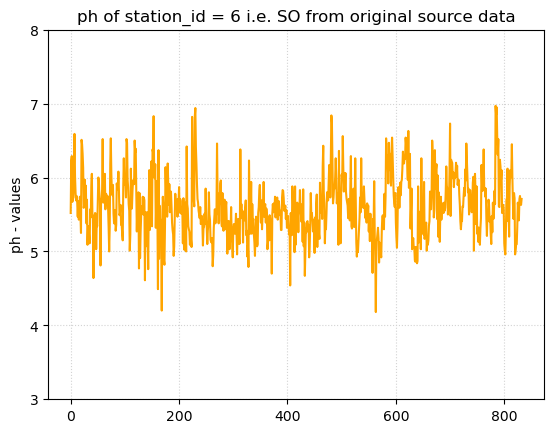

In [76]:
df = df.sort_values(by=['Datum'])
df.head()

df_7 = df_c.loc [ (df_c.Ort == 'SO') & ( df_c.Pb_flag ==1 ) & ( df_c.Cd_flag == 1 )  ]

x = list(range(len(df_7)))
y = df_7['pH']

plt.title('ph of station_id = 6 i.e. SO from original source data')
plt.plot( x, y , label= 'ph', color = 'orange')
plt.ylabel('ph - values')
ax = plt.gca()
ax.set_ylim([3, 8])
plt.grid(ls= ':', color = 'lightgray')
plt.show()


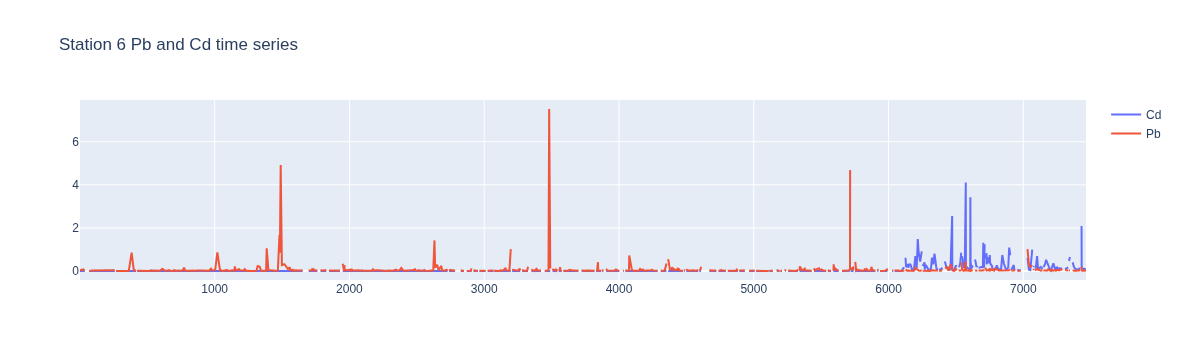

In [123]:
X = station_6_data_pb_cd_ph.measurement_id
CD = station_6_data_pb_cd_ph.pb
PB = station_6_data_pb_cd_ph.cd

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=X, y=CD,
                    mode='lines',
                    name='Cd'))
fig.add_trace(go.Scatter(x=X, y=PB,
                    mode='lines',
                    name='Pb'))
fig.update_layout(
    title = 'Station 6 Pb and Cd time series - VIEW Retrieval'
)

fig.show()

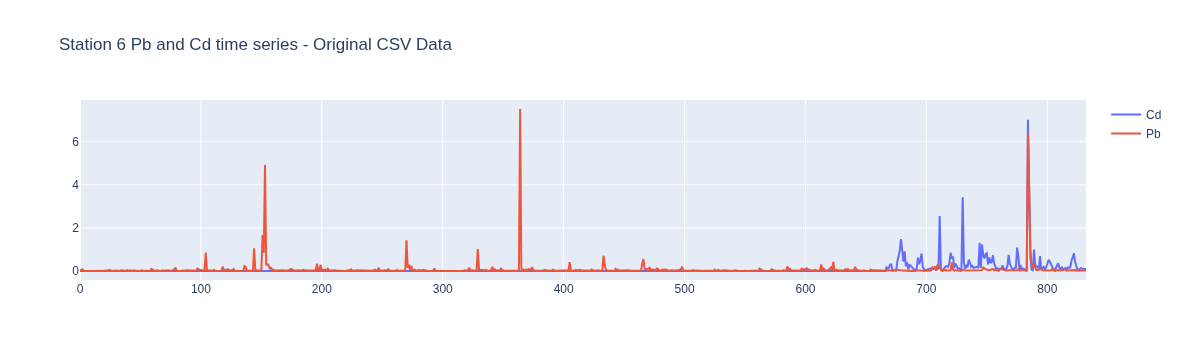

In [78]:
import plotly.graph_objects as go

fig = go.Figure()

x = x # dummy dates indicator
y1 = df_7.Pb.astype(float)
y2 = df_7.Cd.astype(float)

fig.add_trace(go.Scatter(x=x, y=y1,
                    mode='lines',
                    name='Cd'))
fig.add_trace(go.Scatter(x=x, y=y2,
                    mode='lines',
                    name='Pb'))
fig.update_layout(
    title = 'Station 6 Pb and Cd time series - Original CSV Data'
)

fig.show()


In [151]:
TABLE_NAME = 'precipitation_measurements'

## View for stations with the highest precipitation recorded
view_query = QueryDefinition(
    datasources=[TABLE_NAME],
    
    columns=[
        f"{TABLE_NAME}.station_id",
        f"{TABLE_NAME}.ns",
        f"{TABLE_NAME}.measurement_id",
    ],

    filters=[
        FilterDefinition(
            type=FilterType.WHERE,
            column=f"{TABLE_NAME}.ns",
            operator=">",
            value="100",
        )
    ],
    orders=[
        OrderDefinition(
            column=f"{TABLE_NAME}.measurement_id",
            direction=OrderType.ASC,
        )
    ],
)

view = client.create_view(
    database_id=DATABASE_ID,
    name="stations_high_precipitation",
    query=view_query,
    is_public=False,
    is_schema_public=False,
)

print("Created view id:", view.id)
print("Created view name:", view.name)

VIEW_ID = view.id

Created view id: 7d8b25aa-5a7d-4858-94a1-34808e3b0bb5
Created view name: stations_high_precipitation


In [152]:
print("Waiting for asynchronous view creation to map...")
time.sleep(5)

for _ in range(10):
    try:
        df_view = client.get_view_data(
            database_id=DATABASE_ID,
            view_id=VIEW_ID,
            page=0,
            size=1000000,
        )
        print('df from VIEW created *** ')
        break
    except Exception as e:
        if '204' in str(e):
            print("Still waiting for view...")
            time.sleep(5)
        else:
            raise e

Waiting for asynchronous view creation to map...
df from VIEW created *** 


In [153]:
df_view.head()

,measurement_id,ns,station_id
0,8535,5.834777585210861,3
1,3208,22.819179664933568,5
2,105,2.9,14
3,8174,4.4,11
4,116,2.2,14


In [156]:
len(stations_high_precipitation)

6349

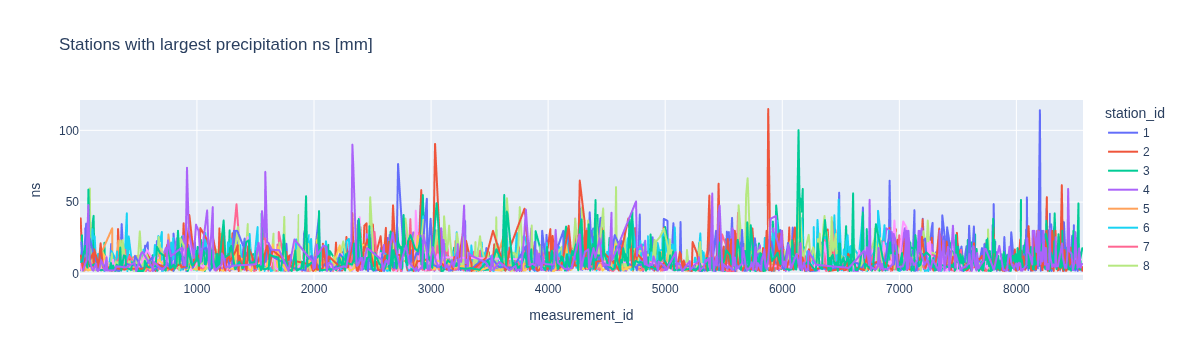

In [163]:
# Formatting DataFrame
stations_high_precipitation = df_view
stations_high_precipitation['measurement_id'] = stations_high_precipitation['measurement_id'].astype('int').values
stations_high_precipitation['ns'] = stations_high_precipitation['ns'].astype('float').values
stations_high_precipitation['station_id'] = stations_high_precipitation['station_id'].astype('int').values
stations_high_precipitation = stations_high_precipitation.sort_values(by=['measurement_id'])
stations_high_precipitation = stations_high_precipitation.sort_values(by=['station_id','measurement_id'])

import plotly.express as px

fig = px.line(stations_high_precipitation, 
                 x="measurement_id", 
                 y="ns", 
                 color="station_id",
                 title="Stations with largest precipitation ns [mm] ")

fig.show()

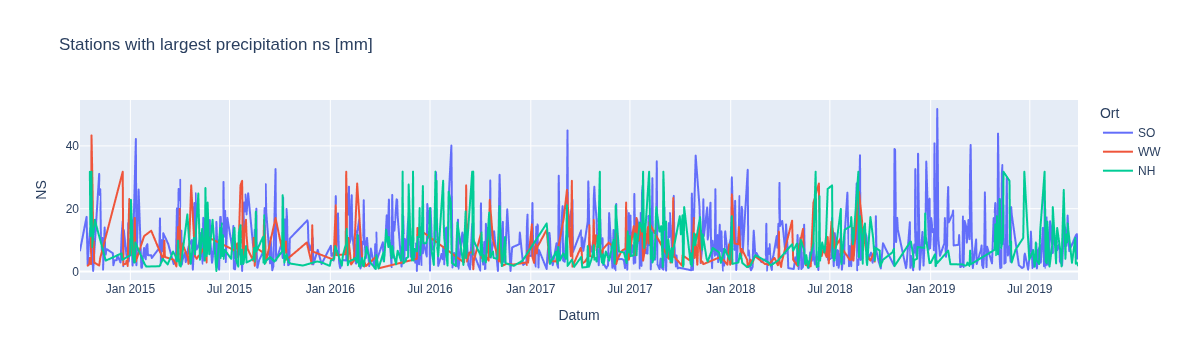

In [79]:
import plotly.express as px

fig = px.line(df_c, 
                 x="Datum", 
                 y="NS", 
                 color="Ort",
                 title="Stations with largest precipitation ns [mm] ")

fig.show()